In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations

from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                   cross_val_predict, KFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, precision_recall_curve, log_loss)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn import linear_model
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV

import xgboost as xgb
import lightgbm as lgb


from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier

import shap

import time
from datetime import datetime
from scipy.optimize import minimize
from scipy.stats import rankdata

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

print("Все библиотеки успешно импортированы!")
print("Убедитесь, что установлены: pip install xgboost lightgbm catboost shap optuna")
print(f"Версии:")
print(f"   XGBoost: {xgb.__version__}")
print(f"   LightGBM: {lgb.__version__}")
RANDOM_STATE = 42


Все библиотеки успешно импортированы!
Убедитесь, что установлены: pip install xgboost lightgbm catboost shap optuna
Версии:
   XGBoost: 3.2.0
   LightGBM: 4.6.0


In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train = train.dropna()

In [ ]:
df = train
print(f'Размер: {df.shape}')
print(f'Классы: {df["Transported"].value_counts().to_dict()}')
train.head(5)

Размер: (6606, 14)
Классы: {True: 3327, False: 3279}


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6606 non-null   object 
 1   HomePlanet    6606 non-null   object 
 2   CryoSleep     6606 non-null   object 
 3   Cabin         6606 non-null   object 
 4   Destination   6606 non-null   object 
 5   Age           6606 non-null   float64
 6   VIP           6606 non-null   object 
 7   RoomService   6606 non-null   float64
 8   FoodCourt     6606 non-null   float64
 9   ShoppingMall  6606 non-null   float64
 10  Spa           6606 non-null   float64
 11  VRDeck        6606 non-null   float64
 12  Name          6606 non-null   object 
 13  Transported   6606 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 729.0+ KB


In [ ]:
(train.isna().mean() * 100).round(2).sort_values(ascending=False)

,0
PassengerId,0.0
HomePlanet,0.0
CryoSleep,0.0
Cabin,0.0
Destination,0.0
Age,0.0
VIP,0.0
RoomService,0.0
FoodCourt,0.0
ShoppingMall,0.0


In [ ]:
train['Transported'] = train['Transported'].map({True: 1, False: 0})
train['VIP'] = train['VIP'].map({True: 1, False: 0})
train['CryoSleep'] = train['CryoSleep'].map({True: 1, False: 0})

In [ ]:
train.drop(['PassengerId', 'Cabin', 'Name'], axis=1, inplace=True)

In [ ]:
ohe = OneHotEncoder(drop='if_binary')

In [ ]:
X_object = train.select_dtypes('object')
ohe.fit(X_object)

OneHotEncoder(drop='if_binary')

In [ ]:
data = train

In [ ]:
codes = ohe.transform(X_object).toarray()

In [ ]:
print(ohe.feature_names_in_)

['HomePlanet' 'Destination']


In [ ]:
feature_names = ohe.get_feature_names_out()  # без аргументов!

In [ ]:
#feature_names = ohe.get_feature_names_out(['HomePlanet', 'Destination', 'deck', 'num', 'side'])
feature_names

array(['HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_55 Cancri e', 'Destination_PSO J318.5-22',
       'Destination_TRAPPIST-1e'], dtype=object)

In [ ]:
data_coded = pd.concat([data.select_dtypes(exclude = 'object'), pd.DataFrame(codes,
                                                            columns=feature_names).astype(int)], axis = 1)

In [ ]:
data_coded

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,24.0,0.0,109.0,9.0,25.0,549.0,44.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,16.0,0.0,303.0,70.0,151.0,565.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0
6600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0
6601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,0.0,0.0
6602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X = data_coded.drop('Transported', axis=1)
y = data_coded['Transported']
np.random.seed(100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
class_names = ['TRUE', 'FALSE']
feature_cols1 = ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_nan', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_nan']

In [ ]:
print('Все колонки:', data_coded.columns.tolist())

Все колонки: ['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


In [ ]:
# Словарь для сбора результатов всех моделей
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Обучить, предсказать, сохранить результаты."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'f1_macro': f1}
    print(f'{name}: accuracy={acc:.4f}, F1-macro={f1:.4f}')
    return y_pred

In [ ]:
mask = ~y_train.isna()
X_train = X_train[mask]
y_train = y_train[mask]

In [ ]:
mask_test = ~pd.Series(y_test).isna()
X_test = X_test[mask_test.values]
y_test = y_test[mask_test.values]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2,
                             random_state=RANDOM_STATE, n_jobs=-1)
y_pred_rf = evaluate_model('RandomForest', rf, X_train, X_test, y_train, y_test)

print(classification_report(y_test, y_pred_rf, target_names=class_names))

RandomForest: accuracy=0.7855, F1-macro=0.7853
              precision    recall  f1-score   support

        TRUE       0.79      0.77      0.78       969
       FALSE       0.78      0.80      0.79      1003

    accuracy                           0.79      1972
   macro avg       0.79      0.79      0.79      1972
weighted avg       0.79      0.79      0.79      1972



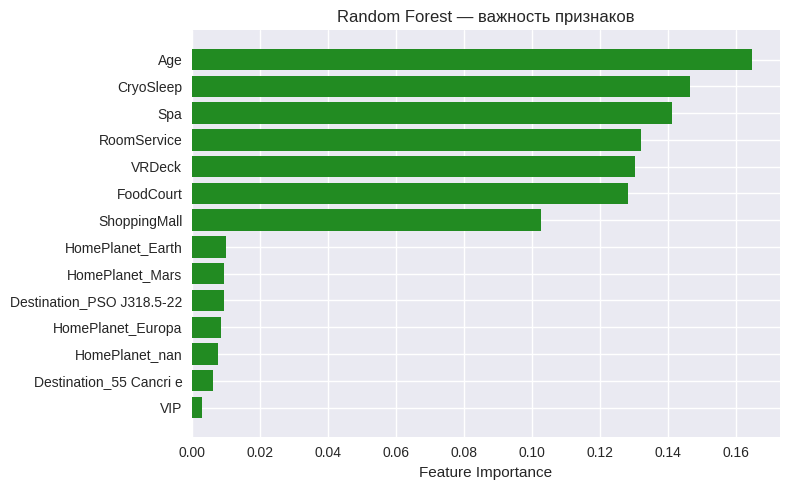

In [ ]:
# Feature importance (Random Forest)
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(importances)), importances[sorted_idx], color='forestgreen')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(np.array(feature_cols1)[sorted_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — важность признаков')
plt.tight_layout()
plt.show()

In [ ]:
df = data_coded

In [ ]:
print(df.columns.tolist())

['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


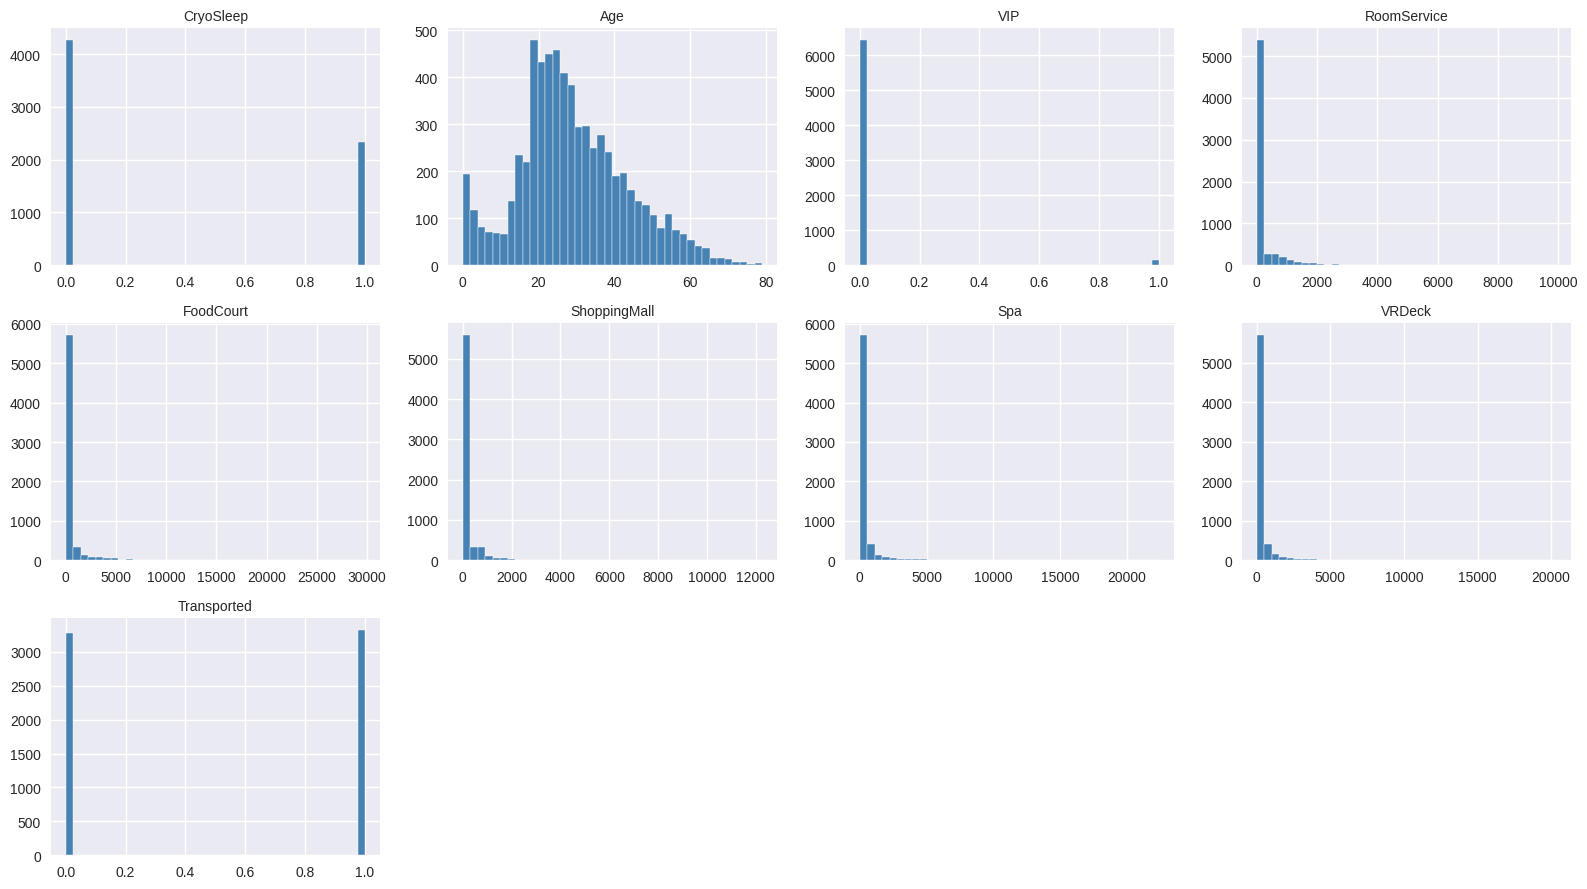

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Оставляет строку только если во ВСЕХ числовых колонках значение <= 99.5 перцентиля
col_names = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
num_cols = df[col_names]  # DataFrame, а не список
thresholds = num_cols.quantile(0.99)

clean_data = df[(num_cols.le(thresholds) | num_cols.isna()).all(axis=1)]


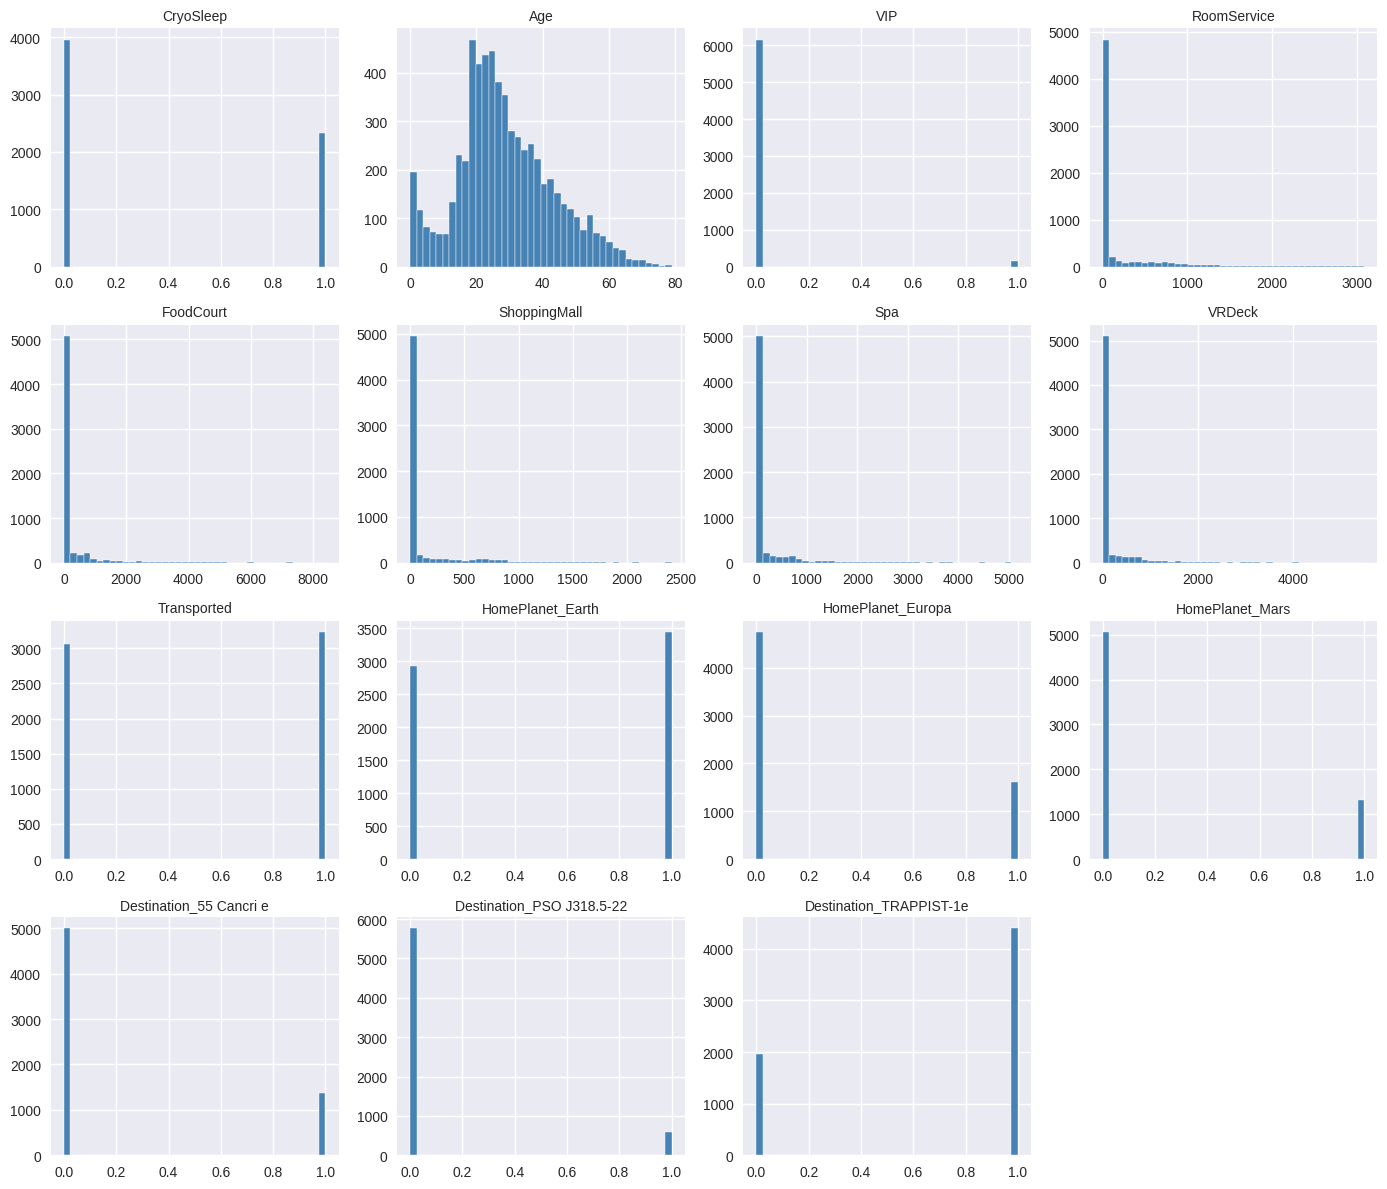

In [ ]:
numeric_cols = clean_data.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    clean_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
feature_cols = ['CryoSleep', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'HomePlanet_Earth', 'HomePlanet_Europa','Destination_PSO J318.5-22']
feature_cols1 = ['CryoSleep', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'HomePlanet_Earth', 'HomePlanet_Europa','Destination_PSO J318.5-22']
# Сначала оставь только строки где Transported не NaN
clean_data_model = clean_data[feature_cols1 + ['Transported']].dropna()

X = clean_data_model[feature_cols1].values
y = LabelEncoder().fit_transform(clean_data_model['Transported'])

class_names = ['TRUE', 'FALSE']

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
clean_data = clean_data[feature_cols]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Распределение классов (train): {np.bincount(y_train)}')

Train: (3805, 10), Test: (952, 10)
Распределение классов (train): [1828 1977]


In [ ]:
clean_data['Transported']

,Transported
0,0.0
1,1.0
3,0.0
4,1.0
5,1.0
...,...
6591,NaN
6600,NaN
6601,NaN
6602,NaN


Корреляционная матрица

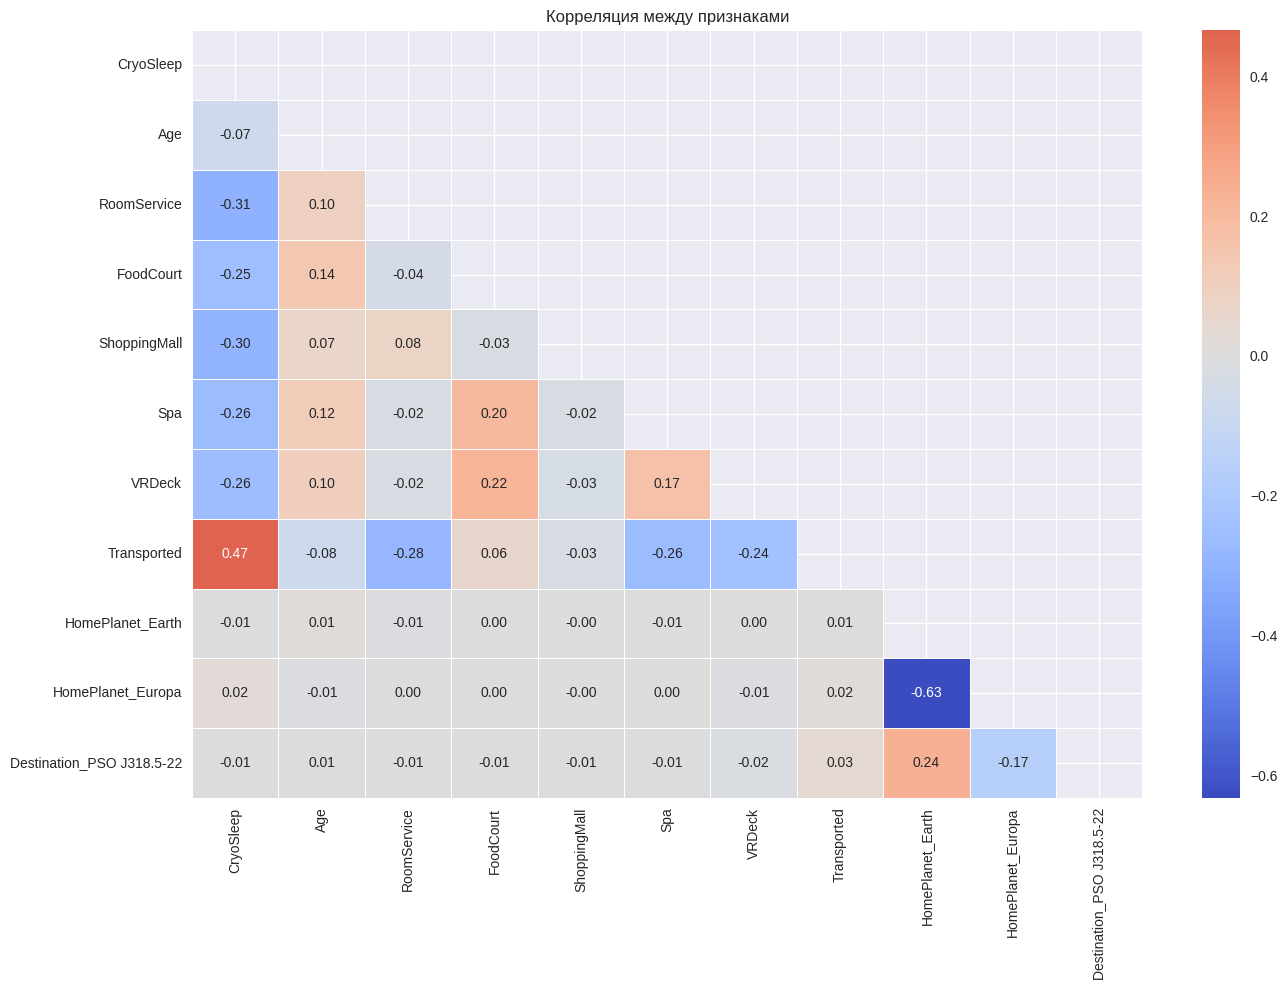

In [ ]:
plt.figure(figsize=(14, 10))
corr = clean_data[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [ ]:
# Словарь для сбора результатов всех моделей
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Обучить, предсказать, сохранить результаты."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'f1_macro': f1}
    print(f'{name}: accuracy={acc:.4f}, F1-macro={f1:.4f}')
    return y_pred

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # или 'median'

X_train_sc = imputer.fit_transform(X_train_sc)
X_test_sc = imputer.transform(X_test_sc)  # только transform, не fit!


Наивный Байес

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
y_pred_nb = evaluate_model('GaussianNB', gnb, X_train_sc, X_test_sc, y_train, y_test)

print(classification_report(y_test, y_pred_nb, target_names=class_names))

GaussianNB: accuracy=0.7353, F1-macro=0.7226
              precision    recall  f1-score   support

        TRUE       0.85      0.54      0.66       457
       FALSE       0.68      0.91      0.78       495

    accuracy                           0.74       952
   macro avg       0.77      0.73      0.72       952
weighted avg       0.76      0.74      0.72       952



In [ ]:
print(class_names)           # что там сейчас
print(np.unique(y_test))     # какие реальные классы


['TRUE', 'FALSE']
[0 1]


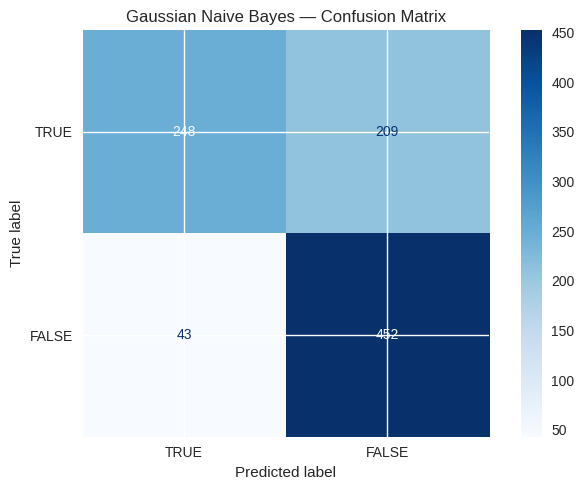

In [ ]:
# Confusion matrix для NB
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, display_labels=class_names, ax=ax, cmap='Blues')
ax.set_title('Gaussian Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Калибровка вероятностей NB
proba_nb = gnb.predict_proba(X_test_sc)
print('Пример предсказанных вероятностей (первые 5 объектов):')
print(pd.DataFrame(proba_nb[:5], columns=class_names).round(4))
print(f'\nСредняя максимальная уверенность: {proba_nb.max(axis=1).mean():.3f}')

Пример предсказанных вероятностей (первые 5 объектов):
     TRUE   FALSE
0  0.0026  0.9974
1  0.9983  0.0017
2  1.0000  0.0000
3  0.0076  0.9924
4  0.0511  0.9489

Средняя максимальная уверенность: 0.915


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Подбор оптимального K
k_range = [1, 11, 15, 21, 26, 31, 51, 61, 71, 101]
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())
    print(f'K={k:3d}: CV accuracy = {scores.mean():.4f} ± {scores.std():.4f}')

best_k = k_range[np.argmax(cv_scores)]
print(f'\nЛучший K = {best_k}')

K=  1: CV accuracy = 0.6725 ± 0.0194
K= 11: CV accuracy = 0.7698 ± 0.0161
K= 15: CV accuracy = 0.7716 ± 0.0103
K= 21: CV accuracy = 0.7756 ± 0.0141
K= 26: CV accuracy = 0.7740 ± 0.0165
K= 31: CV accuracy = 0.7737 ± 0.0175
K= 51: CV accuracy = 0.7708 ± 0.0184
K= 61: CV accuracy = 0.7716 ± 0.0165
K= 71: CV accuracy = 0.7674 ± 0.0197
K=101: CV accuracy = 0.7656 ± 0.0185

Лучший K = 21


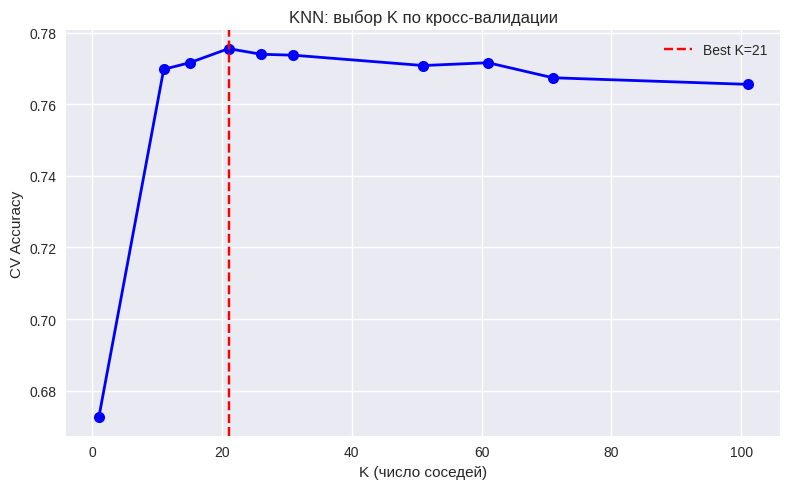

In [ ]:
# Визуализация: accuracy vs K
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, cv_scores, 'b-o', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('K (число соседей)')
ax.set_ylabel('CV Accuracy')
ax.set_title('KNN: выбор K по кросс-валидации')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Финальная оценка KNN с лучшим K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
y_pred_knn = evaluate_model('KNN', knn_best, X_train_sc, X_test_sc, y_train, y_test)
print(classification_report(y_test, y_pred_knn, target_names=class_names))

KNN: accuracy=0.7763, F1-macro=0.7743
              precision    recall  f1-score   support

        TRUE       0.80      0.71      0.75       457
       FALSE       0.76      0.84      0.80       495

    accuracy                           0.78       952
   macro avg       0.78      0.77      0.77       952
weighted avg       0.78      0.78      0.78       952



In [ ]:
# Сравнение KNN с нормализацией и без
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k)
knn_no_scale.fit(X_train, y_train)
acc_no_scale = accuracy_score(y_test, knn_no_scale.predict(X_test))

knn_scaled = KNeighborsClassifier(n_neighbors=best_k)
knn_scaled.fit(X_train_sc, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_sc))

print(f'KNN БЕЗ нормализации: {acc_no_scale:.4f}')
print(f'KNN С нормализацией:  {acc_scaled:.4f}')
print(f'Разница: {(acc_scaled - acc_no_scale)*100:+.2f}%')

KNN БЕЗ нормализации: 0.7847
KNN С нормализацией:  0.7763
Разница: -0.84%


SVM

In [ ]:
from sklearn.svm import SVC, LinearSVC

# SVM на подвыборке (полный датасет слишком большой для RBF SVM)
# Берём 10K для быстроты
np.random.seed(RANDOM_STATE)
sample_size = min(10000, len(X_train_sc))
idx_sub = np.random.choice(len(X_train_sc), size=sample_size, replace=False)

X_train_sub = X_train_sc[idx_sub]
y_train_sub = y_train[idx_sub]

# Линейный SVM
linear_svm = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)
y_pred_lsvm = evaluate_model('LinearSVM', linear_svm, X_train_sub, X_test_sc, y_train_sub, y_test)

# RBF SVM
rbf_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
y_pred_rsvm = evaluate_model('RBF-SVM', rbf_svm, X_train_sub, X_test_sc, y_train_sub, y_test)

LinearSVM: accuracy=0.7721, F1-macro=0.7716
RBF-SVM: accuracy=0.7931, F1-macro=0.7918


In [ ]:
# Подбор C для SVM (GridSearch на подвыборке)
param_grid = {'C': [0.1, 1, 10, 100]}
gs_svm = GridSearchCV(SVC(kernel='rbf', gamma='scale', random_state=RANDOM_STATE),
                      param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train_sub, y_train_sub)

print('Результаты Grid Search (RBF SVM):')
for params, mean_score, std_score in zip(
    gs_svm.cv_results_['params'], gs_svm.cv_results_['mean_test_score'], gs_svm.cv_results_['std_test_score']):
    print(f"  C={params['C']:5.1f}: {mean_score:.4f} ± {std_score:.4f}")
print(f'\nЛучшие параметры: {gs_svm.best_params_}, score={gs_svm.best_score_:.4f}')

# Оценка лучшего SVM
y_pred_svm_best = gs_svm.predict(X_test_sc)
results['SVM-best'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm_best),
    'f1_macro': f1_score(y_test, y_pred_svm_best, average='macro')
}
print(f"\nSVM-best на тесте: accuracy={results['SVM-best']['accuracy']:.4f}")

Результаты Grid Search (RBF SVM):
  C=  0.1: 0.7614 ± 0.0094
  C=  1.0: 0.7787 ± 0.0036
  C= 10.0: 0.7703 ± 0.0104
  C=100.0: 0.7656 ± 0.0059

Лучшие параметры: {'C': 1}, score=0.7787

SVM-best на тесте: accuracy=0.7952


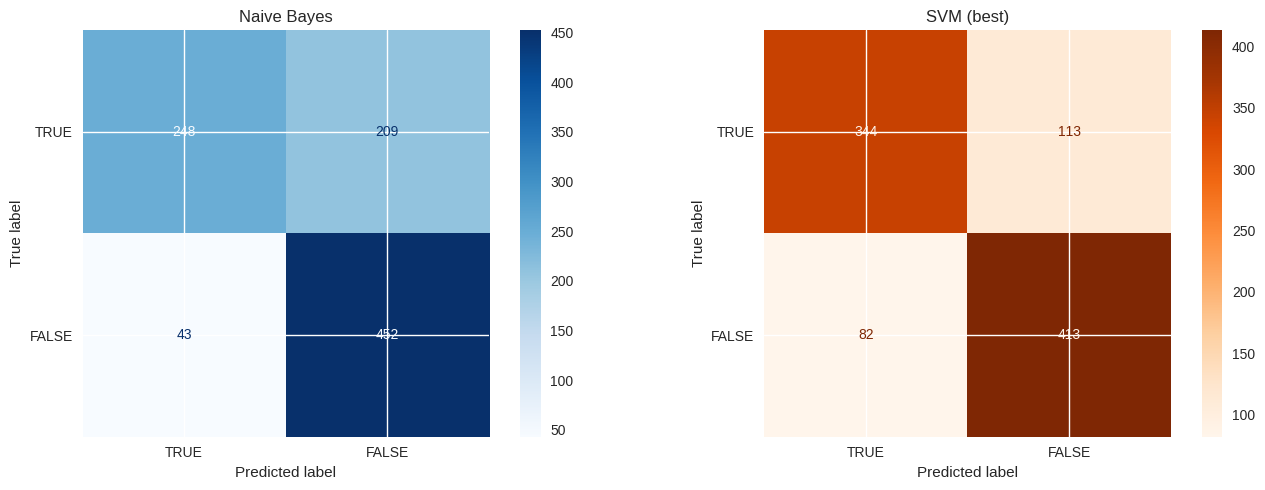

In [ ]:
# Confusion matrix для лучшего SVM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, display_labels=class_names, ax=axes[0], cmap='Blues')
axes[0].set_title('Naive Bayes')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_best, display_labels=class_names, ax=axes[1], cmap='Oranges')
axes[1].set_title('SVM (best)')
plt.tight_layout()
plt.show()

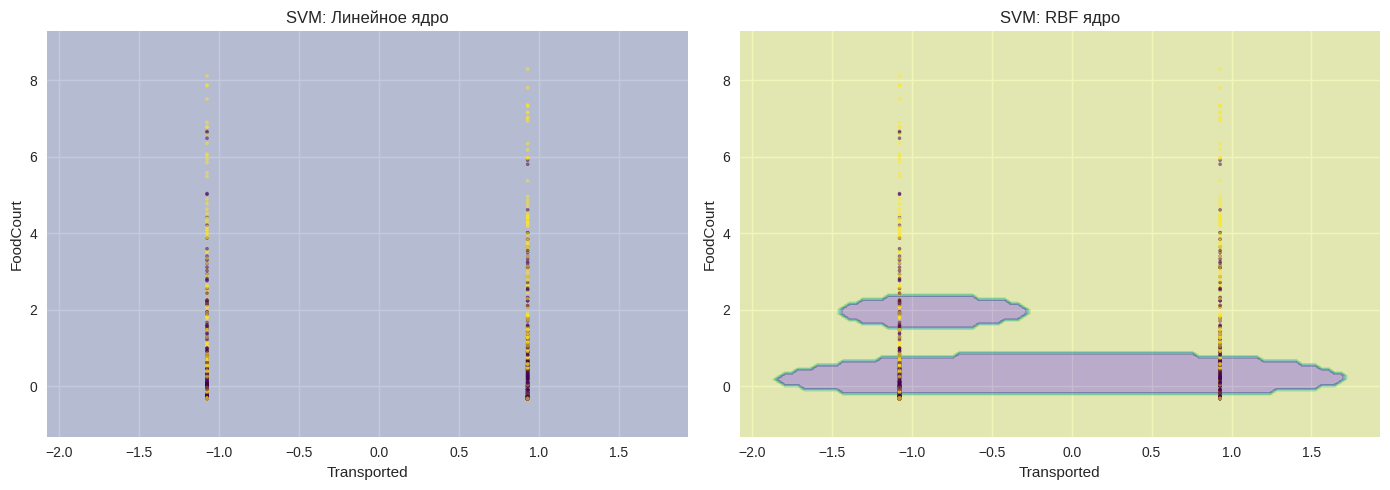

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

# 2D SVM demo на двух признаках
feat_a, feat_b = 7, 3  # redshift, g
X_2d = X_train_sc[:5000, [feat_a, feat_b]]
y_2d = y_train[:5000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, kernel, title in zip(axes, ['linear', 'rbf'], ['Линейное ядро', 'RBF ядро']):
    clf = SVC(kernel=kernel, C=10, gamma='scale', random_state=RANDOM_STATE)
    clf.fit(X_2d, y_2d)
    DecisionBoundaryDisplay.from_estimator(clf, X_2d, ax=ax, alpha=0.3, cmap='viridis',
                                            response_method='predict')
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='viridis', s=5, alpha=0.5)
    ax.set_xlabel(feature_cols[feat_a])
    ax.set_ylabel(feature_cols[feat_b])
    ax.set_title(f'SVM: {title}')

plt.tight_layout()
plt.show()

Бустинг

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Sklearn GradientBoosting (базовый)
gb_sklearn = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                         random_state=RANDOM_STATE)
y_pred_gb = evaluate_model('GradientBoosting', gb_sklearn, X_train, X_test, y_train, y_test)

GradientBoosting: accuracy=0.7742, F1-macro=0.7723


In [ ]:
import time

# Попробуем XGBoost
try:
    from xgboost import XGBClassifier
    t0 = time.time()
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                         random_state=RANDOM_STATE, use_label_encoder=False,
                         eval_metric='mlogloss', n_jobs=-1, verbosity=0)
    y_pred_xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)
    print(f'  Время: {time.time()-t0:.1f}s')
except ImportError:
    print('XGBoost не установлен. pip install xgboost')

XGBoost: accuracy=0.7794, F1-macro=0.7776
  Время: 1.5s


In [ ]:
# LightGBM
try:
    from lightgbm import LGBMClassifier
    t0 = time.time()
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    y_pred_lgbm = evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test)
    print(f'  Время: {time.time()-t0:.1f}s')
except ImportError:
    print('LightGBM не установлен. pip install lightgbm')

LightGBM: accuracy=0.7679, F1-macro=0.7657
  Время: 0.8s


In [ ]:
# CatBoost
try:
    from catboost import CatBoostClassifier
    t0 = time.time()
    cb = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6,
                             random_state=RANDOM_STATE, verbose=0)
    y_pred_cb = evaluate_model('CatBoost', cb, X_train, X_test, y_train, y_test)
    print(f'  Время: {time.time()-t0:.1f}s')
except ImportError:
    print('CatBoost не установлен. pip install catboost')

CatBoost: accuracy=0.7721, F1-macro=0.7698
  Время: 6.4s


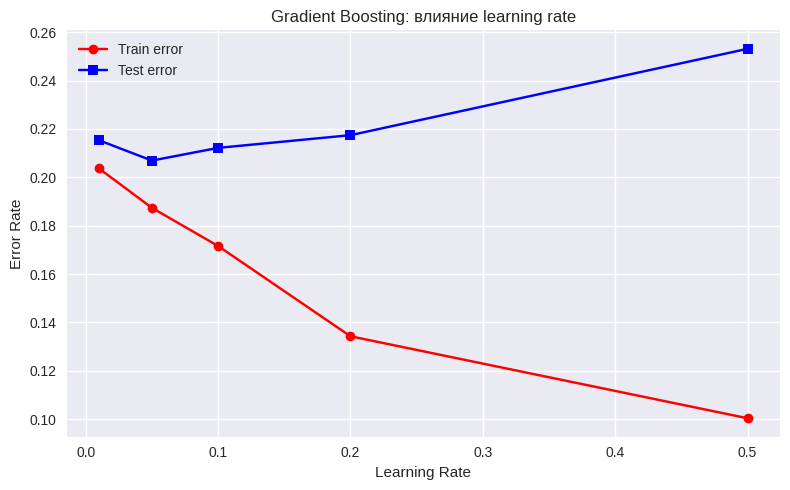

In [ ]:
# Влияние learning rate на качество бустинга
from sklearn.ensemble import GradientBoostingClassifier

lrs = [0.01, 0.05, 0.1, 0.2, 0.5]
train_errs = []
test_errs = []

for lr in lrs:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=4,
                                     random_state=RANDOM_STATE, subsample=0.8)
    gb.fit(X_train, y_train)
    train_errs.append(1 - accuracy_score(y_train, gb.predict(X_train)))
    test_errs.append(1 - accuracy_score(y_test, gb.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lrs, train_errs, 'r-o', label='Train error')
ax.plot(lrs, test_errs, 'b-s', label='Test error')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Error Rate')
ax.set_title('Gradient Boosting: влияние learning rate')
ax.legend()
plt.tight_layout()
plt.show()

Стекинг

In [ ]:
# === Блендинг вручную ===
from sklearn.linear_model import LogisticRegression

# Делим train на 2 части
X_blend_train, X_blend_val, y_blend_train, y_blend_val = train_test_split(
    X_train_sc, y_train, test_size=0.3, random_state=RANDOM_STATE, stratify=y_train)

# Базовые модели
base_models = [
    ('nb', GaussianNB()),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
]

# Обучаем на 70% train, предсказываем на 30% (blend_val) и на test
meta_train = np.zeros((len(X_blend_val), len(base_models)))
meta_test = np.zeros((len(X_test_sc), len(base_models)))

for i, (name, model) in enumerate(base_models):
    model.fit(X_blend_train, y_blend_train)
    meta_train[:, i] = model.predict(X_blend_val)
    meta_test[:, i] = model.predict(X_test_sc)
    print(f'  {name}: val_acc={accuracy_score(y_blend_val, meta_train[:, i]):.4f}')

# Мета-модель
meta_clf = LogisticRegression(random_state=RANDOM_STATE, max_iter=500)
meta_clf.fit(meta_train, y_blend_val)
y_pred_blend = meta_clf.predict(meta_test)

results['Blending'] = {
    'accuracy': accuracy_score(y_test, y_pred_blend),
    'f1_macro': f1_score(y_test, y_pred_blend, average='macro')
}
print(f"\nBlending: accuracy={results['Blending']['accuracy']:.4f}, "
      f"F1-macro={results['Blending']['f1_macro']:.4f}")

  nb: val_acc=0.7522
  knn: val_acc=0.7574
  rf: val_acc=0.7644

Blending: accuracy=0.7731, F1-macro=0.7712


In [ ]:
# === Стекинг через sklearn ===
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ('nb', GaussianNB()),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                           max_depth=4, random_state=RANDOM_STATE)),
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
    cv=5, n_jobs=-1
)

t0 = time.time()
y_pred_stack = evaluate_model('Stacking', stacking, X_train_sc, X_test_sc, y_train, y_test)
print(f'  Время: {time.time()-t0:.1f}s')
print(classification_report(y_test, y_pred_stack, target_names=class_names))

Stacking: accuracy=0.7826, F1-macro=0.7798
  Время: 12.0s
              precision    recall  f1-score   support

        TRUE       0.82      0.70      0.76       457
       FALSE       0.76      0.86      0.80       495

    accuracy                           0.78       952
   macro avg       0.79      0.78      0.78       952
weighted avg       0.79      0.78      0.78       952



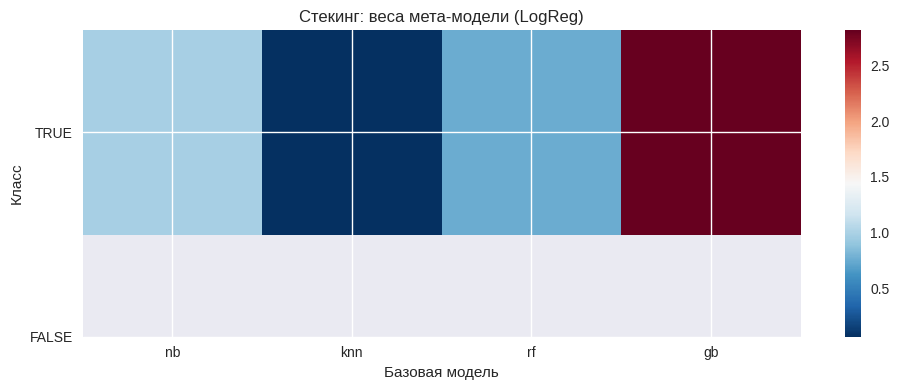

In [ ]:
# Визуализация: веса мета-модели (какой базовый классификатор вносит больше всего)
meta_weights = stacking.final_estimator_.coef_
base_names = [name for name, _ in stacking.estimators]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(meta_weights, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(base_names)))
ax.set_xticklabels(base_names)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names)
ax.set_xlabel('Базовая модель')
ax.set_ylabel('Класс')
ax.set_title('Стекинг: веса мета-модели (LogReg)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()